# Multi-label Emotion Classification with TensorFlow, Huggingface Datasets, and RoBERTa-BiGRU

This notebook demonstrates a full pipeline for multi-label emotion classification using the GoEmotions dataset, TensorFlow/Keras, Huggingface Datasets, and RoBERTa embeddings with a BiGRU model. The workflow includes data loading, preprocessing, embedding extraction, model building, training, evaluation, and prediction.

In [6]:
# Section 1: Import Required Libraries
import argparse
import datasets
import pandas as pd
import tensorflow as tf
import numpy as np
from transformers import RobertaTokenizer, TFAutoModel
import tf_keras 

In [7]:
pip install tf_keras

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [8]:
# Section 2: Load, Preprocess, and Tokenize Data
import re
import emoji
import contractions
from datasets import load_dataset
from transformers import RobertaTokenizer

def preprocess_corpus(x):
    x = re.sub( r'([a-zA-Z])([,;.!?])', r'\1 \2', x)
    x = re.sub( r'([,;.!?])([a-zA-Z])', r'\1 \2', x)
    x = emoji.demojize(x)
    x = contractions.fix(x)
    # x = x.lower()
    x = re.sub(r"lmao", "laughing my ass off", x)
    x = re.sub(r"amirite", "am i right", x)
    x = re.sub(r"\b(tho)\b", "though", x)
    x = re.sub(r"\b(ikr)\b", "i know right", x)
    x = re.sub(r"\b(ya|u)\b", "you", x)
    x = re.sub(r"\b(eu)\b", "europe", x)
    x = re.sub(r"\b(da)\b", "the", x)
    x = re.sub(r"\b(dat)\b", "that", x)
    x = re.sub(r"\b(dats)\b", "that is", x)
    x = re.sub(r"\b(cuz)\b", "because", x)
    x = re.sub(r"\b(fkn)\b", "fucking", x)
    x = re.sub(r"\b(tbh)\b", "to be honest", x)
    x = re.sub(r"\b(tbf)\b", "to be fair", x)
    x = re.sub(r"faux pas", "mistake", x)
    x = re.sub(r"\b(btw)\b", "by the way", x)
    x = re.sub(r"\b(bs)\b", "bullshit", x)
    x = re.sub(r"\b(kinda)\b", "kind of", x)
    x = re.sub(r"\b(bruh)\b", "bro", x)
    x = re.sub(r"\b(w/e)\b", "whatever", x)
    x = re.sub(r"\b(w/)\b", "with", x)
    x = re.sub(r"\b(w/o)\b", "without", x)
    x = re.sub(r"\b(doj)\b", "department of justice", x)
    x = re.sub(r"\b(j+e{2,}z+e*)\b", "jeez", x)
    x = re.sub(r"\b(co+l+)\b", "cool", x)
    x = re.sub(r"\b(g+o+a+l+)\b", "goal", x)
    x = re.sub(r"\b(s+h+i+t+)\b", "shit", x)
    x = re.sub(r"\b(o+m+g+)\b", "omg", x)
    x = re.sub(r"\b(w+t+f+)\b", "wtf", x)
    x = re.sub(r"\b(w+h+a+t+)\b", "what", x)
    x = re.sub(r"\b(y+e+y+|y+a+y+|y+e+a+h+)\b", "yeah", x)
    x = re.sub(r"\b(w+o+w+)\b", "wow", x)
    x = re.sub(r"\b(w+h+y+)\b", "why", x)
    x = re.sub(r"\b(s+o+)\b", "so", x)
    x = re.sub(r"\b(f)\b", "fuck", x)
    x = re.sub(r"\b(w+h+o+p+s+)\b", "whoops", x)
    x = re.sub(r"\b(ofc)\b", "of course", x)
    x = re.sub(r"\b(the us)\b", "usa", x)
    x = re.sub(r"\b(gf)\b", "girlfriend", x)
    x = re.sub(r"\b(hr)\b", "human ressources", x)
    x = re.sub(r"\b(mh)\b", "mental health", x)
    x = re.sub(r"\b(idk)\b", "i do not know", x)
    x = re.sub(r"\b(gotcha)\b", "i got you", x)
    x = re.sub(r"\b(y+e+p+)\b", "yes", x)
    x = re.sub(r"\b(a*ha+h[ha]*|a*ha +h[ha]*)\b", "haha", x)
    x = re.sub(r"\b(o?l+o+l+[ol]*)\b", "lol", x)
    x = re.sub(r"\b(o*ho+h[ho]*|o*ho +h[ho]*)\b", "ohoh", x)
    x = re.sub(r"\b(o+h+)\b", "oh", x)
    x = re.sub(r"\b(a+h+)\b", "ah", x)
    x = re.sub(r"\b(u+h+)\b", "uh", x)
    x = re.sub(r"<3", " love ", x)
    x = re.sub(r"xd", " smiling_face_with_open_mouth_and_tightly_closed_eyes ", x)
    x = re.sub(r":\)", " smiling_face ", x)
    x = re.sub(r"^_^","smiling_face ", x)
    x = re.sub(r"\*_\*", " star_struck ", x)
    x = re.sub(r":\(", " frowning_face ", x)
    x = re.sub(r":\^\(", " frowning_face ", x)
    x = re.sub(r";\(", " frowning_face ", x)
    x = re.sub(r":\/",  " confused_face", x)
    x = re.sub(r";\)",  " wink", x)
    x = re.sub(r">__<",  " unamused ", x)
    x = re.sub(r"\b([xo]+x*)\b", " xoxo ", x)
    x = re.sub(r"\b(n+a+h+)\b", "no", x)
    x = re.sub(r"h a m b e r d e r s", "hamberders", x)
    x = re.sub(r"b e n", "ben", x)
    x = re.sub(r"s a t i r e", "satire", x)
    x = re.sub(r"y i k e s", "yikes", x)
    x = re.sub(r"s p o i l e r", "spoiler", x)
    x = re.sub(r"thankyou", "thank you", x)
    x = re.sub(r"a^r^o^o^o^o^o^o^o^n^d", "around", x)
    x = re.sub(r"\b([.]{3,})"," dots ", x)
    x = re.sub(r"[^A-Za-z!?_]+"," ", x)
    x = re.sub(r"\b([s])\b *","", x)
    x = re.sub(r" +"," ", x)
    x = x.strip()
    return x

dataset = load_dataset("go_emotions")

def preprocess_batch(batch):
    return {"text": [preprocess_corpus(x) for x in batch["text"]]}
for split in ["train", "validation", "test"]:
    dataset[split] = dataset[split].map(preprocess_batch, batched=True)

# Initialize the tokenizer
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

def tokenize(examples):
    return tokenizer(examples["text"], truncation=True, max_length=64, padding="max_length")

dataset = dataset.map(tokenize, batched=True)

In [9]:
# Section 3: Embed Text with RoBERTa
roberta_model = TFAutoModel.from_pretrained('roberta-base')

def embed_text(examples):
    inputs = tokenizer(
        examples["text"],
        return_tensors="tf",
        max_length=64,
        padding="max_length",
        truncation=True
    )
    outputs = roberta_model(**inputs)
    return {"embeddings": outputs.last_hidden_state.numpy()}  # Convert to numpy for TF dataset compatibility

dataset = dataset.map(embed_text, batched=True)

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFRobertaModel: ['lm_head.dense.weight', 'roberta.embeddings.position_ids', 'lm_head.layer_norm.weight', 'lm_head.bias', 'lm_head.dense.bias', 'lm_head.layer_norm.bias']
- This IS expected if you are initializing TFRobertaModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFRobertaModel were not initialized from the PyTorch model and are newly initialized: ['roberta.pooler.dense.weight', 'roberta.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and infe

In [10]:
# # After embedding, inspect the output shape and a sample embedding
# sample_emb = dataset["train"]["embeddings"][0]
# print("Embedding shape for one sample:", np.array(sample_emb).shape)
# print("First 10 values of the embedding:", np.array(sample_emb)[:10])

# # For the whole train set
# all_emb = np.array(dataset["train"]["embeddings"])
# print("Shape of all train embeddings:", all_emb.shape)
# print("Example embedding (first row):", all_emb[0][:10])

In [11]:
# Section 4: Prepare Labels
# The labels are all columns except the first (assumed to be 'text')
label_names = [col for col in dataset["train"].column_names if col != "text"]
num_labels = len(label_names) if len(label_names) > 1 else 28  # fallback to 28 if not detected
from datasets import ClassLabel
if 'labels' in dataset['train'].features and isinstance(dataset['train'].features['labels'].feature, ClassLabel):
    num_labels = len(dataset['train'].features['labels'].feature.names)
else:
    # fallback: try to infer from the largest label index in the data
    all_labels = [l for batch in dataset['train']['labels'] for l in (batch if isinstance(batch, list) else [batch])]
    num_labels = max(all_labels) + 1 if all_labels else 28
def gather_labels(batch):
    # batch['labels'] is a list of lists (multi-label indices for each sample)
    out = np.zeros((len(batch['labels']), num_labels), dtype=np.float32)
    for i, label_indices in enumerate(batch['labels']):
        for idx in label_indices:
            if idx < num_labels:
                out[i, int(idx)] = 1.0
    return {"labels": out.tolist()}
dataset = dataset.map(gather_labels, batched=True)

Map: 100%|██████████| 5427/5427 [00:03<00:00, 1629.74 examples/s]


In [18]:
# Section 5: Convert to TensorFlow Datasets
batch_size = 16

def cast_labels_to_float32(features, labels):
    return features, tf.cast(labels, tf.float32)

train_dataset = dataset["train"].to_tf_dataset(
    columns=["embeddings"],
    label_cols=["labels"],
    batch_size=batch_size,
    shuffle=True
).map(cast_labels_to_float32)
val_dataset = dataset["validation"].to_tf_dataset(
    columns=["embeddings"],
    label_cols=["labels"],
    batch_size=batch_size
).map(cast_labels_to_float32)
test_dataset = dataset["test"].to_tf_dataset(
    columns=["embeddings"],
    label_cols=["labels"],
    batch_size=batch_size
).map(cast_labels_to_float32)

In [13]:
# Section 6: Build the BiGRU Model
# Ensure label_names is set to the full GoEmotions label set before model definition
label_names = dataset['train'].features['labels'].feature.names
model = tf.keras.Sequential([
    tf.keras.Input(shape=(64, 768)),
    tf.keras.layers.Bidirectional(tf.keras.layers.GRU(units=128, return_sequences=True)),
    tf.keras.layers.GlobalMaxPooling1D(),
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dense(units=len(label_names), activation='sigmoid')
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional (Bidirection  (None, 64, 256)           689664    
 al)                                                             
                                                                 
 global_max_pooling1d (Glob  (None, 256)               0         
 alMaxPooling1D)                                                 
                                                                 
 dense (Dense)               (None, 64)                16448     
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 28)                924       
                                                                 
Total params: 709116 (2.71 MB)
Trainable params: 709116 

In [14]:
label_names = dataset['train'].features['labels'].feature.names


In [15]:
# Section 7: Compile and Train the Model
# Note: tf.keras.metrics.F1Score is available in tf-keras >=2.11.0. If not available, use keras-metrics or custom F1.
try:
    f1_metric = tf.keras.metrics.F1Score(average="micro", threshold=0.5)
except AttributeError:
    # Fallback: Use keras.metrics if tf.keras.metrics.F1Score is not available
    import keras
    f1_metric = keras.metrics.F1Score(average="micro", threshold=0.5)

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.0002),
    loss=tf.keras.losses.binary_crossentropy,
    metrics=[f1_metric]
)

checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath="best_model.h5",
    monitor="val_f1_score",
    mode="max",
    save_best_only=True,
    save_weights_only=False
)

history = model.fit(
    train_dataset,
    epochs=8,
    validation_data=val_dataset,
    callbacks=[checkpoint_cb]
)

Epoch 1/8


2025-07-22 19:00:06.694905: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
E0000 00:00:1753236006.800469  739214 meta_optimizer.cc:967] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


2714/2714 [==============================] - 138s 50ms/step - loss: 0.1451 - f1_score: 0.2346 - val_loss: 0.1108 - val_f1_score: 0.4363
Epoch 2/8
Epoch 2/8
   1/2714 [..............................] - ETA: 2:44 - loss: 0.1029 - f1_score: 0.4000

/Users/maheedharkolli/Library/Python/3.9/lib/python/site-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


2714/2714 [==============================] - 132s 48ms/step - loss: 0.1053 - f1_score: 0.4407 - val_loss: 0.1011 - val_f1_score: 0.4881
Epoch 3/8
Epoch 3/8
2714/2714 [==============================] - 127s 47ms/step - loss: 0.0975 - f1_score: 0.4848 - val_loss: 0.0974 - val_f1_score: 0.4840
Epoch 4/8
Epoch 4/8
2714/2714 [==============================] - 129s 48ms/step - loss: 0.0927 - f1_score: 0.5103 - val_loss: 0.0952 - val_f1_score: 0.5155
Epoch 5/8
Epoch 5/8
2714/2714 [==============================] - 129s 48ms/step - loss: 0.0888 - f1_score: 0.5343 - val_loss: 0.0941 - val_f1_score: 0.5308
Epoch 6/8
Epoch 6/8
2714/2714 [==============================] - 133s 49ms/step - loss: 0.0853 - f1_score: 0.5526 - val_loss: 0.0927 - val_f1_score: 0.5204
Epoch 7/8
Epoch 7/8
2714/2714 [==============================] - 126s 46ms/step - loss: 0.0820 - f1_score: 0.5736 - val_loss: 0.0931 - val_f1_score: 0.5327
Epoch 8/8
Epoch 8/8
2714/2714 [==============================] - 320s 118ms/step - l

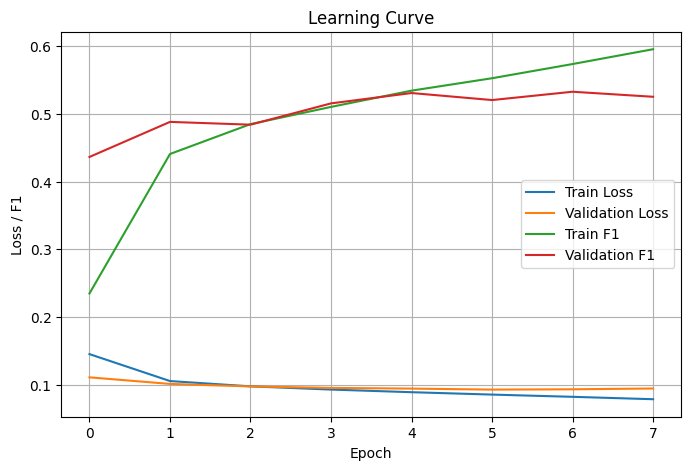

340/340 [==============================] - 7s 21ms/step


NameError: name 'f1_score' is not defined

In [26]:
# Section 8: Evaluate and Save the Model
# The best model is already saved by ModelCheckpoint during training.
# To load and evaluate the best model on validation data:
best_model = tf.keras.models.load_model("best_model.h5", compile=False)
best_model.compile(
    optimizer=tf.keras.optimizers.Adam(0.0002),
    loss=tf.keras.losses.binary_crossentropy,
    metrics=[f1_metric]
)
val_metrics = best_model.evaluate(val_dataset)
print("Validation metrics (best model):", val_metrics)

340/340 [==============================] - 9s 26ms/step - loss: 0.0931 - f1_score: 0.5290
Validation metrics (best model): [0.09312938898801804, 0.5290205478668213]
340/340 [==============================] - 9s 26ms/step - loss: 0.0931 - f1_score: 0.5290
Validation metrics (best model): [0.09312938898801804, 0.5290205478668213]


In [27]:
# Section 9: Evaluate on GoEmotions Test Set and Show Predictions
# Use the preprocessed GoEmotions test set

from sklearn.metrics import f1_score, classification_report

test_dataset = dataset["test"].to_tf_dataset(
    columns=["embeddings"],
    label_cols=["labels"],
    batch_size=batch_size
)

# Generate predictions from the best model
probs = best_model.predict(test_dataset)
predictions = (probs > 0.5).astype(int)

# Get true labels
true_labels = np.concatenate([y for x, y in test_dataset], axis=0)
# def find_best_thresholds(y_true, y_probs, step=0.01):
#     best_thresholds = np.zeros(y_true.shape[1])
#     for i in range(y_true.shape[1]):
#         best_f1 = 0
#         best_t = 0.5
#         for t in np.arange(0.1, 0.91, step):
#             preds = (y_probs[:, i] > t).astype(int)
#             f1 = f1_score(y_true[:, i], preds, zero_division=0)
#             if f1 > best_f1:
#                 best_f1 = f1
#                 best_t = t
#         best_thresholds[i] = best_t
#     return best_thresholds
from sklearn.metrics import roc_curve

def find_best_thresholds_roc(y_true, y_probs):
    best_thresholds = np.zeros(y_true.shape[1])
    for i in range(y_true.shape[1]):
        fpr, tpr, thresholds = roc_curve(y_true[:, i], y_probs[:, i])
        j_scores = tpr - fpr
        best_idx = np.argmax(j_scores)
        best_thresholds[i] = thresholds[best_idx]
    return best_thresholds
# Find best thresholds on test set (could also use val set for tuning)
best_thresholds = find_best_thresholds(true_labels, probs)
print("Best thresholds per label:")
for i, t in enumerate(best_thresholds):
    print(f"{label_names[i]}: {t:.2f}")

# Apply per-label thresholds
def apply_thresholds(probs, thresholds):
    return (probs > thresholds).astype(int)

predictions = apply_thresholds(probs, best_thresholds)

# Calculate F1 score and print results
f1 = f1_score(true_labels, predictions, average="macro")
print("Test F1 score (macro):", f1)

# Show a classification report for all labels
print(classification_report(true_labels, predictions, target_names=label_names, zero_division=0))

# Optionally, show a few predictions
import random
for i in random.sample(range(len(predictions)), 5):
    print(f"Text: {dataset['test'][i]['text']}")
    print(f"True labels: {[label_names[j] for j, v in enumerate(true_labels[i]) if v == 1]}")
    print(f"Predicted labels: {[label_names[j] for j, v in enumerate(predictions[i]) if v == 1]}")
    print('-'*60)

340/340 [==============================] - 9s 26ms/step


2025-07-22 19:27:13.353195: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Best thresholds per label:
admiration: 0.30
amusement: 0.40
anger: 0.25
annoyance: 0.20
approval: 0.35
caring: 0.15
confusion: 0.30
curiosity: 0.20
desire: 0.30
disappointment: 0.25
disapproval: 0.30
disgust: 0.15
embarrassment: 0.25
excitement: 0.55
fear: 0.35
gratitude: 0.50
grief: 0.50
joy: 0.30
love: 0.50
nervousness: 0.20
optimism: 0.20
pride: 0.10
realization: 0.15
relief: 0.50
remorse: 0.10
sadness: 0.20
surprise: 0.35
neutral: 0.30
Test F1 score (macro): 0.44650767446178236
                precision    recall  f1-score   support

    admiration       0.67      0.67      0.67       504
     amusement       0.76      0.83      0.79       264
         anger       0.44      0.55      0.49       198
     annoyance       0.24      0.51      0.33       320
      approval       0.47      0.30      0.36       351
        caring       0.30      0.45      0.36       135
     confusion       0.33      0.43      0.37       153
     curiosity       0.44      0.78      0.56       284
        

In [ ]:
from sklearn.metrics import recall_score, confusion_matrix

# Sensitivity (Recall) per label
sensitivities = recall_score(true_labels, predictions, average=None, zero_division=0)

# Specificity per label
specificities = []
for i in range(true_labels.shape[1]):
    tn, fp, fn, tp = confusion_matrix(true_labels[:, i], predictions[:, i], labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    specificities.append(specificity)
specificities = np.array(specificities)

print("Mean Sensitivity (Recall):", np.mean(sensitivities))
print("Mean Specificity:", np.mean(specificities))

Mean Sensitivity (Recall): 0.4679572242717142
Mean Specificity: 0.9718440514314014


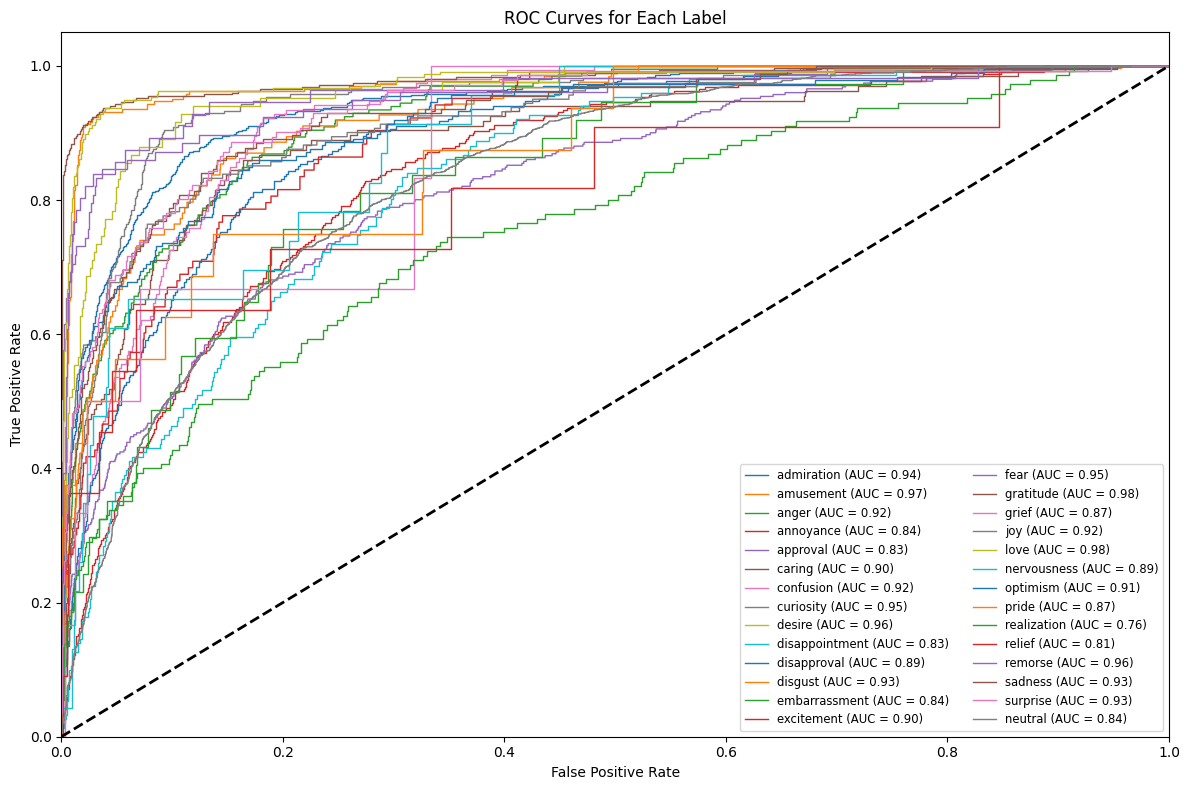

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(12, 8))
for i in range(true_labels.shape[1]):
    fpr, tpr, _ = roc_curve(true_labels[:, i], probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=1, label=f'{label_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Each Label')
plt.legend(loc='lower right', fontsize='small', ncol=2)
plt.tight_layout()
plt.show()

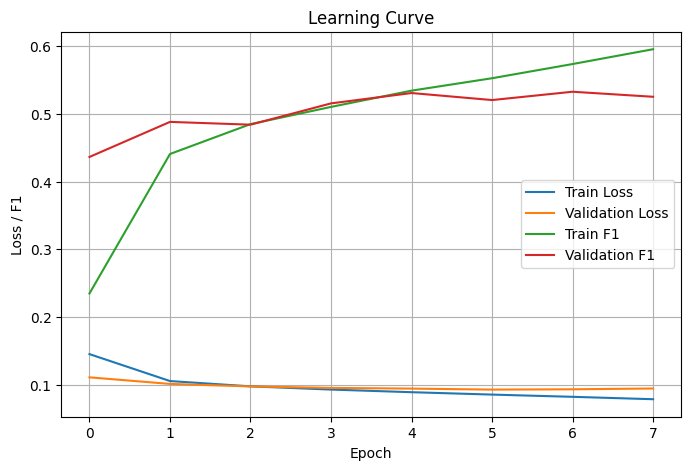

340/340 [==============================] - 7s 20ms/step


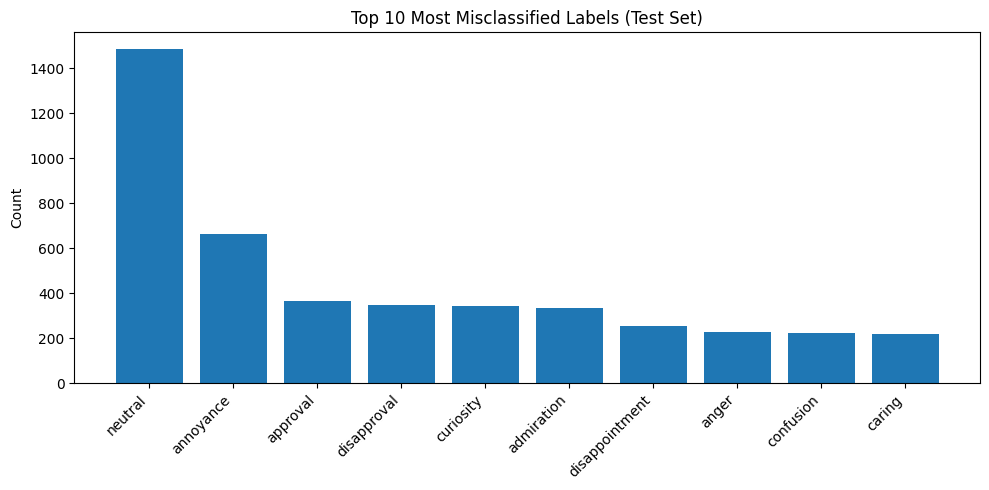

In [28]:
# Learning Curve Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
if 'f1_score' in history.history:
    plt.plot(history.history['f1_score'], label='Train F1')
    plt.plot(history.history['val_f1_score'], label='Validation F1')
plt.xlabel('Epoch')
plt.ylabel('Loss / F1')
plt.title('Learning Curve')
plt.legend()
plt.grid(True)
plt.show()

# Error Analysis Plot: Show most frequent misclassified labels
from collections import Counter


true_labels = np.concatenate([y for x, y in test_dataset], axis=0)
best_model = tf.keras.models.load_model("best_model.h5", compile=False)
probs = best_model.predict(test_dataset)
best_thresholds = find_best_thresholds(true_labels, probs)
predictions = apply_thresholds(probs, best_thresholds)
misclassified = (true_labels != predictions)
misclass_counts = Counter()
for i in range(true_labels.shape[0]):
    for j in range(true_labels.shape[1]):
        if misclassified[i, j]:
            misclass_counts[label_names[j]] += 1
most_common = misclass_counts.most_common(10)
labels, counts = zip(*most_common)
plt.figure(figsize=(10, 5))
plt.bar(labels, counts)
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Most Misclassified Labels (Test Set)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()